
              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0-post0.dev0
 Built: Dec  9 2024 17:34:57

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

--- Starting Negative DC Sweep ---



unning Sweep: 100%|██████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 75.05it/s]


--- Starting Positive DC Sweep ---



unning Sweep: 100%|██████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 72.19it/s]


Generating heatmaps for Rebound Bursting...
Generating heatmaps for Tonic Spiking...

Generating line plots for a fixed duration of 300.00 ms...

Displaying all plots...


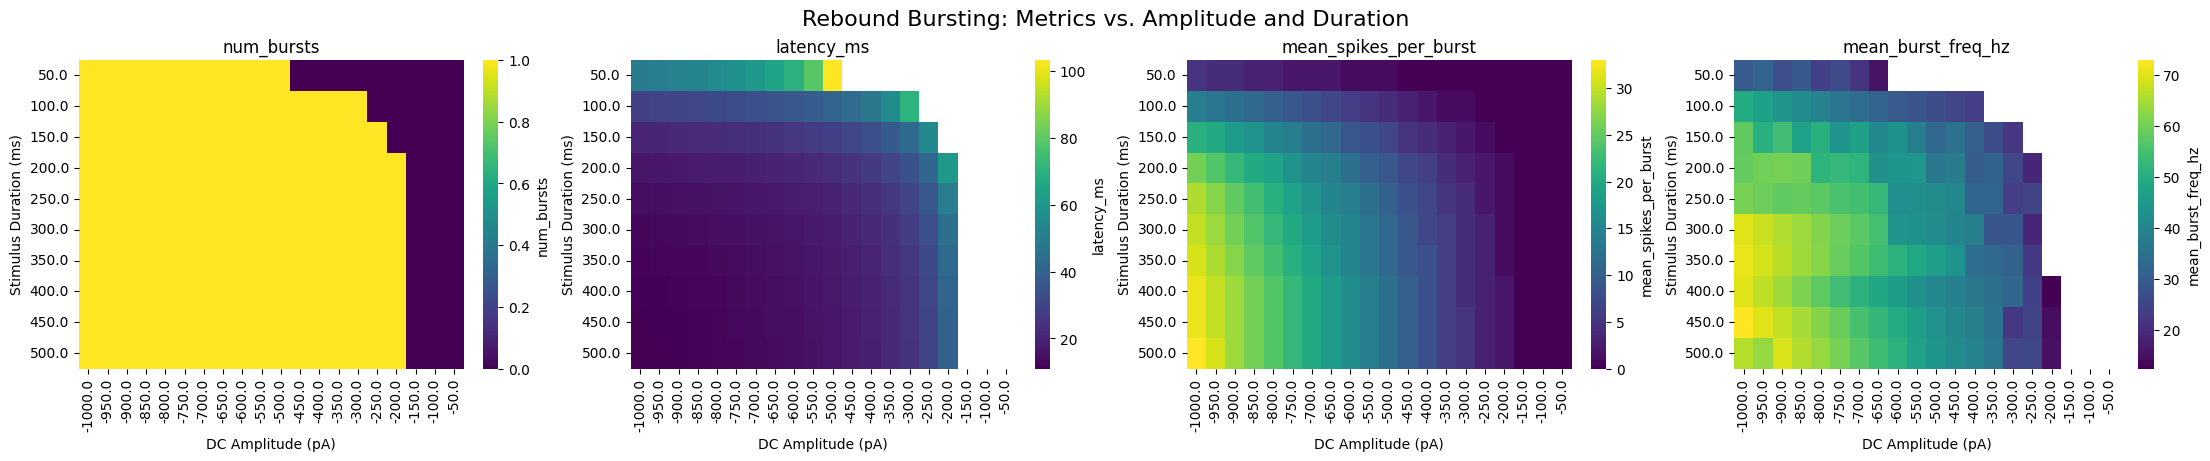

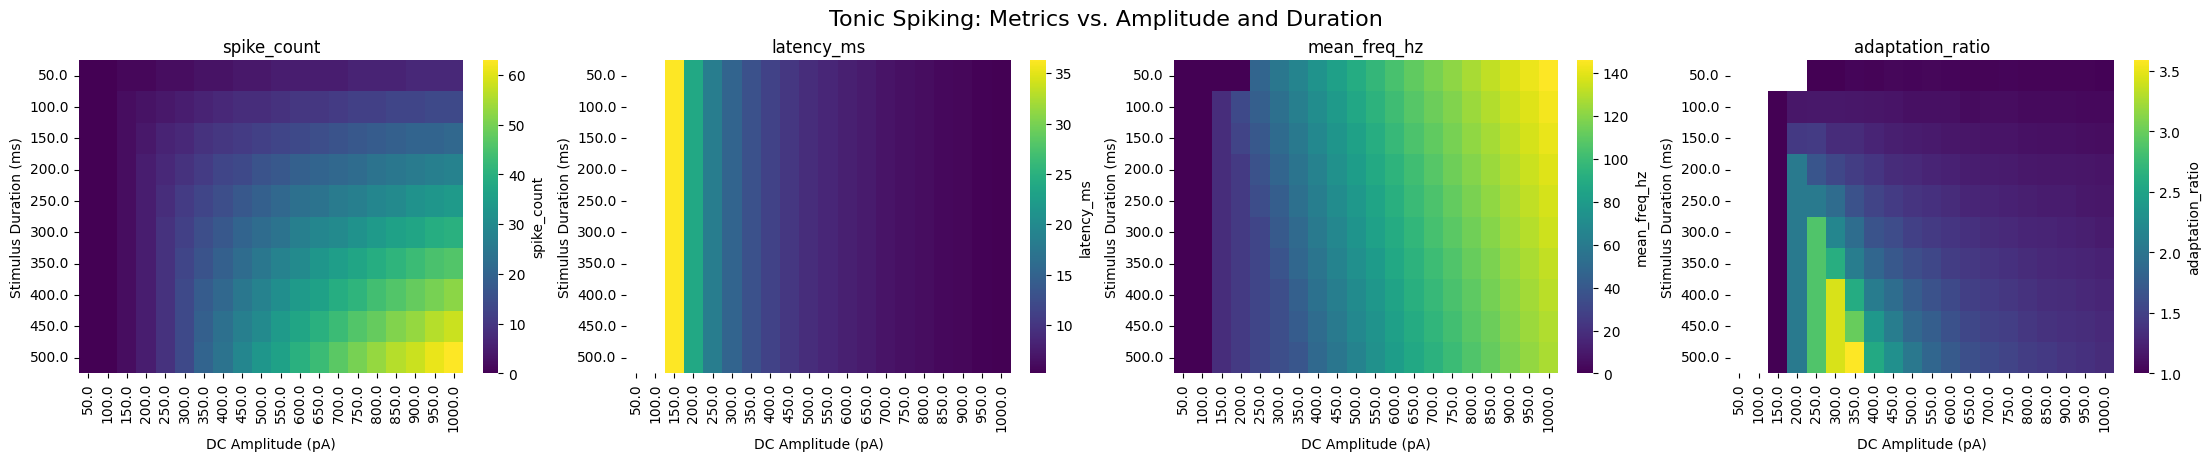

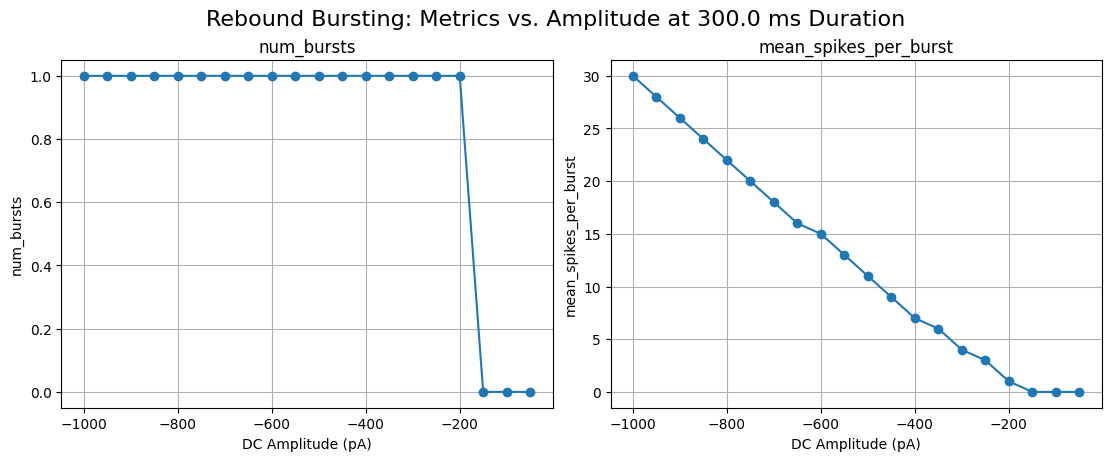

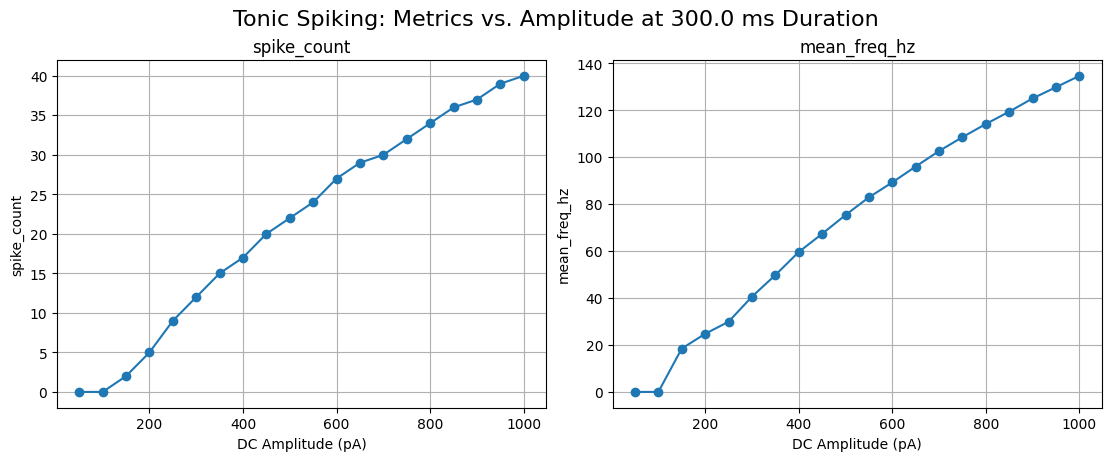

In [1]:
import nest
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# Parameters
params_dict = {
    "C_m": 200.0,         # Membrane capacitance in pF
    "g_L": 10.0,          # Leak conductance in nS
    "E_L": -60.0,         # Leak reversal potential in mV
    "Delta_T": 2.5,       # Slope factor in mV
    "V_th": -50.0,        # Spike initiation threshold in mV
    "V_reset": -60.0,     # Reset potential after a spike in mV
    "V_peak": 0.0,        # Spike cut-off value in mV
    "t_ref": 2.5,         # Refractory period in ms
    "tau_w": 600.0,       # Adaptation time constant in ms
    "a_param": 40.0,      # Subthreshold adaptation coupling in nS
    "b_param": 5.0,       # Spike-triggered adaptation increment in pA
    "I_e": 0,             # External background current in pA
    "tau_decay_AMPA": 5,
    "tau_rise_AMPA": 0.4,
    "tau_decay_GABAA": 20,
    "tau_rise_GABAA": 0.4,
    "tau_decay_GABAB": 200,
    "tau_rise_GABAB": 5,
    "tau_decay_NMDA": 150,
    "tau_rise_NMDA": 2,
}

AMPLITUDES_NEG = np.linspace(-1000, -50, 20)  # pA
AMPLITUDES_POS = np.linspace(50, 1000, 20)    # pA
DURATIONS = np.linspace(50, 500, 10)         # ms
START_DC = 200.0  # ms
SIM_WINDOW_AFTER_PULSE = 800.0 # ms

def analyze_single_run(amplitude_dc, duration):
    """
    Runs a single NEST simulation for a given DC amplitude and duration,
    and returns a dictionary of calculated neurophysiological metrics.
    """
    nest.ResetKernel()
    nest.Install("adex_2expnms_rec_module")
    nest.SetKernelStatus({"print_time": False, "resolution": 0.1})
    end_dc = START_DC + duration
    simtime = end_dc + SIM_WINDOW_AFTER_PULSE
    neuron = nest.Create("adex_2expnms_rec_neuron")
    neuron.set(params_dict)
    dc_current = nest.Create("dc_generator", params={"start": START_DC, "stop": end_dc, "amplitude": amplitude_dc})
    nest.Connect(dc_current, neuron)
    spikerecorder = nest.Create("spike_recorder")
    nest.Connect(neuron, spikerecorder)
    nest.Simulate(simtime)
    spike_times = spikerecorder.get("events")["times"]
    metrics = {}
    
    # CASE 1: Negative DC -> Rebound Bursting Analysis
    if amplitude_dc < 0:
        spike_times_after_pulse = spike_times[spike_times >= end_dc]
        bursts = []
        if len(spike_times_after_pulse) > 0:
            isi_threshold = 100.0
            current_burst = [spike_times_after_pulse[0]]
            if len(spike_times_after_pulse) > 1:
                post_pulse_isis = np.diff(spike_times_after_pulse)
                for i, isi in enumerate(post_pulse_isis):
                    if isi <= isi_threshold:
                        current_burst.append(spike_times_after_pulse[i + 1])
                    else:
                        bursts.append(current_burst)
                        current_burst = [spike_times_after_pulse[i + 1]]
            bursts.append(current_burst)
        metrics['num_bursts'] = len(bursts)
        if not bursts:
            metrics['latency_ms'] = np.nan
            metrics['mean_spikes_per_burst'] = 0
            metrics['mean_burst_duration_ms'] = np.nan
            metrics['mean_burst_freq_hz'] = np.nan
            metrics['mean_ibi_ms'] = np.nan
        else:
            metrics['latency_ms'] = bursts[0][0] - end_dc
            spikes_per_burst = [len(b) for b in bursts]
            metrics['mean_spikes_per_burst'] = np.mean(spikes_per_burst) if spikes_per_burst else 0
            durations_list = [b[-1] - b[0] for b in bursts if len(b) > 1]
            metrics['mean_burst_duration_ms'] = np.mean(durations_list) if durations_list else 0
            freqs = [1000.0 / np.mean(np.diff(b)) for b in bursts if len(b) > 1]
            metrics['mean_burst_freq_hz'] = np.mean(freqs) if freqs else np.nan

            if len(bursts) > 1:
                ibis = [bursts[i+1][0] - bursts[i][-1] for i in range(len(bursts)-1)]
                metrics['mean_ibi_ms'] = np.mean(ibis)
            else:
                metrics['mean_ibi_ms'] = np.nan

    # CASE 2: Positive DC -> Tonic Spiking Analysis
    elif amplitude_dc > 0:
        spike_times_during_pulse = spike_times[(spike_times >= START_DC) & (spike_times <= end_dc)]
        metrics['spike_count'] = len(spike_times_during_pulse)
        
        if metrics['spike_count'] == 0:
            # If no spikes, fill metrics with default values
            metrics['latency_ms'] = np.nan
            metrics['mean_freq_hz'] = 0
            metrics['adaptation_ratio'] = np.nan
            metrics['cv_isi'] = np.nan
        else:
            metrics['latency_ms'] = spike_times_during_pulse[0] - START_DC
            if metrics['spike_count'] > 1:
                isis = np.diff(spike_times_during_pulse)
                metrics['mean_freq_hz'] = 1000.0 / np.mean(isis)
                metrics['cv_isi'] = np.std(isis) / np.mean(isis)
                if len(isis) >= 2:
                    metrics['adaptation_ratio'] = isis[-1] / isis[0]
                else:
                    metrics['adaptation_ratio'] = 1.0
            else:
                metrics['mean_freq_hz'] = 0
                metrics['adaptation_ratio'] = np.nan
                metrics['cv_isi'] = np.nan
    return metrics

def perform_sweep(amplitudes, durations):
    """
    Iterates through all combinations of amplitudes and durations,
    runs the simulation for each, and returns the results in a DataFrame.
    """
    results_list = []
        pbar = tqdm(total=len(amplitudes) * len(durations), desc="Running Sweep")
    for dur in durations:
        for amp in amplitudes:
            run_metrics = analyze_single_run(amp, dur)
            run_metrics['amplitude'] = amp
            run_metrics['duration'] = dur
            results_list.append(run_metrics)
            pbar.update(1)
    pbar.close()
    return pd.DataFrame(results_list)

def plot_heatmaps(df, metrics_to_plot, title_prefix):
    """
    Generates and displays heatmaps for a given set of metrics from a results DataFrame.
    """
    num_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(1, num_metrics, figsize=(num_metrics * 5.5, 4.5), constrained_layout=True)
    if num_metrics == 1:
        axes = [axes]
    fig.suptitle(f'{title_prefix}: Metrics vs. Amplitude and Duration', fontsize=16)
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        if metric in df.columns:
            pivot_df = df.pivot(index='duration', columns='amplitude', values=metric)
            sns.heatmap(pivot_df, ax=ax, cmap='viridis', cbar_kws={'label': metric})
            ax.set_title(metric)
            ax.set_xlabel('DC Amplitude (pA)')
            ax.set_ylabel('Stimulus Duration (ms)')
        else:
            ax.set_title(f'{metric} (not available)')
            ax.axis('off')

def plot_line_graphs(df, metrics_to_plot, duration_to_plot, title_prefix):
    """
    Generates and displays 2D line plots for chosen metrics at a specific duration.
    """
    df_slice = df[df['duration'] == duration_to_plot]
    if df_slice.empty:
        print(f"\nWarning: No data available for duration {duration_to_plot} ms. Skipping line plots.")
        return
    num_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(1, num_metrics, figsize=(num_metrics * 5.5, 4.5), constrained_layout=True)
    if num_metrics == 1:
        axes = [axes]
    fig.suptitle(f'{title_prefix}: Metrics vs. Amplitude at {duration_to_plot} ms Duration', fontsize=16)
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        if metric in df_slice.columns:
            ax.plot(df_slice['amplitude'], df_slice[metric], marker='o', linestyle='-')
            ax.set_title(metric)
            ax.set_xlabel('DC Amplitude (pA)')
            ax.set_ylabel(metric)
            ax.grid(True)
        else:
            ax.set_title(f'{metric} (not available)')
            ax.axis('off')
    
if __name__ == "__main__":
    nest.set_verbosity("M_ERROR")
    print("--- Starting Negative DC Sweep ---")
    neg_results_df = perform_sweep(AMPLITUDES_NEG, DURATIONS)
    print("\n--- Starting Positive DC Sweep ---")
    pos_results_df = perform_sweep(AMPLITUDES_POS, DURATIONS)
    print("\nGenerating heatmaps for Rebound Bursting...")
    neg_heatmap_metrics = ['num_bursts', 'latency_ms', 'mean_spikes_per_burst', 'mean_burst_freq_hz']
    plot_heatmaps(neg_results_df, neg_heatmap_metrics, "Rebound Bursting")
    print("Generating heatmaps for Tonic Spiking...")
    pos_heatmap_metrics = ['spike_count', 'latency_ms', 'mean_freq_hz', 'adaptation_ratio']
    plot_heatmaps(pos_results_df, pos_heatmap_metrics, "Tonic Spiking")
    duration_to_plot = DURATIONS[len(DURATIONS) // 2]
    print(f"\nGenerating line plots for a fixed duration of {duration_to_plot:.2f} ms...")
    neg_line_metrics = ['num_bursts', 'mean_spikes_per_burst']
    plot_line_graphs(neg_results_df, neg_line_metrics, duration_to_plot, "Rebound Bursting")
    pos_line_metrics = ['spike_count', 'mean_freq_hz']
    plot_line_graphs(pos_results_df, pos_line_metrics, duration_to_plot, "Tonic Spiking")
    print("\nDisplaying all plots...")
    plt.show()

